In [1]:
import numpy as np
import optuna
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import StratifiedShuffleSplit

## Carga de datos de entrenamiento, división para obtener algunos de test y ampliación con transformaciones
En esta versión, **primero** se reconstruye cada imagen a tamaño **80x70**, **después** se aplican las transformaciones y **al final** se aplana para entrenar la red fully connected.


In [2]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)
    
    # Si es un .npz, sacamos el primer array que contenga
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data
    
    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


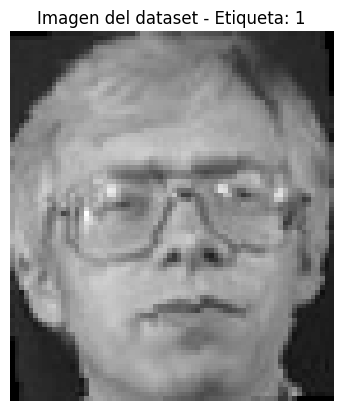

In [3]:
def reconstruir_imagen(img):
    return img.reshape(80, 70)

# Creamos un dataset
dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.long))

img, label = dataset[20]
img_2d = reconstruir_imagen(img)
plt.imshow(img_2d, cmap="gray")
plt.title(f"Imagen del dataset - Etiqueta: {label.item()}")
plt.axis("off")
plt.show()


def make_split(X, Y):
    """5 imágenes por clase en train, 1 en test — estratificado."""
    stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
    train_idx, test_idx = next(stratified_split.split(X, Y))
    print(f'train idx {train_idx}; test_idx: {test_idx} ')

    X_train, Y_train = X[train_idx], Y[train_idx]
    X_test,  Y_test  = X[test_idx],  Y[test_idx]

    print(f"Train: {len(X_train)} imágenes | Test: {len(X_test)} imágenes")
    return (
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long)),
        TensorDataset(torch.tensor(X_test,  dtype=torch.float32), torch.tensor(Y_test,  dtype=torch.long)),
    )

In [4]:
def transform_dataset(dataset):
    transform1 = transforms.Compose([
        transforms.RandomRotation(degrees=15)
    ])
    transform2 = transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0)
    ])
    transform3 = transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5)
    ])
    transform4 = transforms.Compose([
        transforms.RandomPerspective(distortion_scale=0.15, p=0.25)
    ])
    transform5 = transforms.Compose([
        transforms.RandomErasing(p=0.35, scale=(0.02, 0.15), ratio=(0.3, 3.0), value='random')
    ])
    
    images = []
    labels = []

    for img, label in dataset:
        img = img.reshape(1, 80, 70)

        aug_imgs = [
            img,
            transform1(img),
            transform2(img),
            transform3(img),
            transform4(img),
            transform5(img)
        ]

        for im in aug_imgs:
            images.append(im)
            labels.append(label)

    X_aug = torch.stack(images)
    Y_aug = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(X_aug, Y_aug)


In [5]:
dataset_train, test_dataset = make_split(X, Y)
train_dataset = transform_dataset(dataset_train)

N_training = len(train_dataset)
N_test = len(test_dataset)

print(f"Dataset de entrenamiento aumentado: {N_training} imágenes")
print(f"Dataset de test sin aumento: {N_test} imágenes")

train idx [ 79 232 230  80   9 171 146  11 121  93  39 163  78 193  92 120  57 131
 123  76 115  31 139 219 148  46 132   1 214  30 117  73  63 127  81 227
 206  97  56  53 175 215 236  77 141 109  12  52 235 212  15  18 231  37
 239 137 199  91  35 226  19 237 209  38  28  42  50 211 138  54 191 198
 213 207 181  33 195 155 201  22 110  20 151 134 204 118 162 152  74 228
  17  86 220  82  25 114 186 156 205  67  49 182  45 184 144 221  32  27
 111 216 159 142 192 128  34 103 165 107  72  44  90 218 222 188 179 190
 238  65 166 194  10  83 145  13  60 229 126 158  68  41 168 101 176 173
  51 196  55  26  96  62 122 113  61 197  23 202 223 124  99  21 150 180
   2 157 104 130 105  48   3 170 133 160  43 167  70 174 112 102 225  98
   4 187  84 172  64 143  89   8 135 161   6 153  16 119 136  69 233  88
  94 185]; test_idx: [ 14 125 164  71 106 234 140 100 178 217 200  47 177 183 203 154   5 147
 210   0 189  40  87 108  95  58  75 149 129  59 116  29  85   7  24  36
 224 208  66 169] 
T

## Visualización de algunas imágenes tras las transformaciones
Ejecuta esta celda para comparar imágenes del conjunto de entrenamiento **ya reconstruidas a 80x70** con sus versiones rotadas y espejadas.


Definimos la funcion metric para medir el rendimiento de nuestro modelo

In [6]:

class ResNet4(nn.Module): 
    def __init__(self, 
            dim_out,
            activation, 
            apply_bn,
            drop_prob,
            link_function, 
            loss_function
        ):
        super(ResNet4, self).__init__()
        
        self.activation = activation
        self.apply_bn = apply_bn
        self.drop = nn.Dropout2d(drop_prob)
        self.link = link_function
        self.loss = loss_function

        ## ===================== ##
        # Capa de Entrada (1 Canal -> 64 Canales)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        ## ===================== ##
        # RESNET BLOCK 1 (64 -> 64)
        self.b1_conv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn1 = nn.BatchNorm2d(64)
        self.b1_conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn2 = nn.BatchNorm2d(64)

        ## ===================== ##
        # RESNET BLOCK 2 (64 -> 128)
        self.b2_conv1 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False)
        self.b2_bn1 = nn.BatchNorm2d(128)
        self.b2_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b2_bn2 = nn.BatchNorm2d(128)
        
        self.b2_shortcut_conv = nn.Conv2d(64, 128, kernel_size=1, stride=2, padding=0, bias=False)
        self.b2_shortcut_bn = nn.BatchNorm2d(128)

        ## ===================== ##
        # RESNET BLOCK 3 (128 -> 128)
        self.b3_conv1 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b3_bn1 = nn.BatchNorm2d(128)
        self.b3_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b3_bn2 = nn.BatchNorm2d(128)

        ## ===================== ##
        # RESNET BLOCK 4 (128 -> 256)
        self.b4_conv1 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.b4_bn1 = nn.BatchNorm2d(256)
        self.b4_conv2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.b4_bn2 = nn.BatchNorm2d(256)
        
        self.b4_shortcut_conv = nn.Conv2d(128, 256, kernel_size=1, stride=2, padding=0, bias=False)
        self.b4_shortcut_bn = nn.BatchNorm2d(256)
        
        ## ===================== ##
        self.average_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, dim_out)

    def operator(self, x):
        # Reconstruir la imagen 2D si viene aplanada
        if x.dim() == 2 and x.size(1) == 5600:
            x = x.view(-1, 1, 80, 70)

        feature_maps = {}

        x = self.conv1(x)
        if self.apply_bn:
            x = self.bn1(x)
        x = self.activation(x)
        feature_maps['layer1'] = x.clone()

        ## Bloque 1
        x_block = self.b1_conv1(x)
        if self.apply_bn: x_block = self.b1_bn1(x_block)
        x_block = self.b1_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b1_bn2(x_block)
        x = self.drop(self.activation(x + x_block))
        feature_maps['layer2'] = x.clone()

        ## Bloque 2
        x_block = self.b2_conv1(x)
        if self.apply_bn: x_block = self.b2_bn1(x_block)
        x_block = self.b2_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b2_bn2(x_block)
        input_readapted = self.b2_shortcut_conv(x)
        if self.apply_bn: input_readapted = self.b2_shortcut_bn(input_readapted) 
        x = self.drop(self.activation(input_readapted + x_block)) 
        feature_maps['layer3'] = x.clone()

        ## Bloque 3
        x_block = self.b3_conv1(x)
        if self.apply_bn: x_block = self.b3_bn1(x_block)
        x_block = self.b3_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b3_bn2(x_block)
        x = self.drop(self.activation(x + x_block))
        feature_maps['layer4'] = x.clone()

        ## Bloque 4
        x_block = self.b4_conv1(x)
        if self.apply_bn: x_block = self.b4_bn1(x_block)
        x_block = self.b4_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b4_bn2(x_block)
        input_readapted = self.b4_shortcut_conv(x)
        if self.apply_bn: input_readapted = self.b4_shortcut_bn(input_readapted) 
        x = self.drop(self.activation(input_readapted + x_block)) 
        feature_maps['layer5'] = x.clone()

        x = self.average_pooling(x)
        feature_maps['layer_pooling'] = x.clone()
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def forward_train(self, x, apply_link=False):
        self.train()
        x = self.operator(x)
        if apply_link: x = self.link(x)
        return x

    def forward_eval(self, x, apply_link=True): 
        self.eval()
        x = self.operator(x)
        if apply_link: x = self.link(x)
        return x

    def forward(self, x):
        return self.operator(x)

    def compute_loss(self, t, y):
        return self.loss(y, t)

In [7]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            acc += (t == torch.argmax(y, dim=1)).sum().item()
            tot_samples += len(t)

    return acc / tot_samples


def compute_metric_global(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

**DEFINICION DEL MODELO**

In [8]:
def test_model(
    model : torch.nn.Module,
    epochs : int,
    train_batch_size : int,
    lr : float,
    patience : int,
    betas : tuple,
    eps : float,
    weight_decay : float,
    apply_scheduler : bool,
    eval_each : int,
    train_dataset,
    test_dataset
):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    N_training = len(train_dataset)

    loss_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        loss_acc = 0.0
        for batch_idx, (x, t) in enumerate(train_loader_eval):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

        _,_,train_global = compute_metric_global(train_loader_eval, model, k=3)
        _,_,test_global = compute_metric_global(test_loader, model, k=3)

    loss_epochs.append(loss_acc / N_training)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    best_metric = test_global
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())
#---------------------------------------------------------------
    # OPTIMIZADOR: ADAM
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

    # SCHEDULER: ReduceLROnPlateau
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=patience,
        min_lr=1e-6
    )
#-------------------------------------------------------------------

    for e in range(epochs):
        model.train()
        loss_acc = 0.0

        for batch_idx, (x, t) in enumerate(train_loader):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

            L.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end="\r")

        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_global(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_global(test_loader, model, k=3)

            if apply_scheduler:
                scheduler.step(test_global)

            if test_global >= best_metric:
                best_metric = test_global
                best_epoch = e + 1
                best_state_dict = copy.deepcopy(model.state_dict())

            print(" " * 300, end="\r")
            print(
                f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
                f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
                f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
            )
        else:
            print(" " * 300, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc / N_training)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)

    model.load_state_dict(best_state_dict)

    print(f"\nEntrenamiento finalizado. Mejor época: {best_epoch} | test_global: {best_metric:.5f}")

    return loss_epochs, train_global_epochs, test_global_epochs

**MODELO OPTIMIZADO DE ADAM (100%)**

On epoch 1 got loss 3.54290 with train accuracy 0.13167, train top3 0.32333, train global 0.18917 and test accuracy 0.12500, test top3 0.30000, test global 0.17750                                                                                                                                         
On epoch 2 got loss 3.14474 with train accuracy 0.27167, train top3 0.50083, train global 0.34042 and test accuracy 0.25000, test top3 0.52500, test global 0.33250                                                                                                                                         
On epoch 3 got loss 2.88374 with train accuracy 0.34500, train top3 0.62833, train global 0.43000 and test accuracy 0.15000, test top3 0.55000, test global 0.27000                                                                                                                                         
On epoch 4 got loss 2.68720 with train accuracy 0.29500, train top3 0.60000, train global 0.38650

KeyboardInterrupt: 

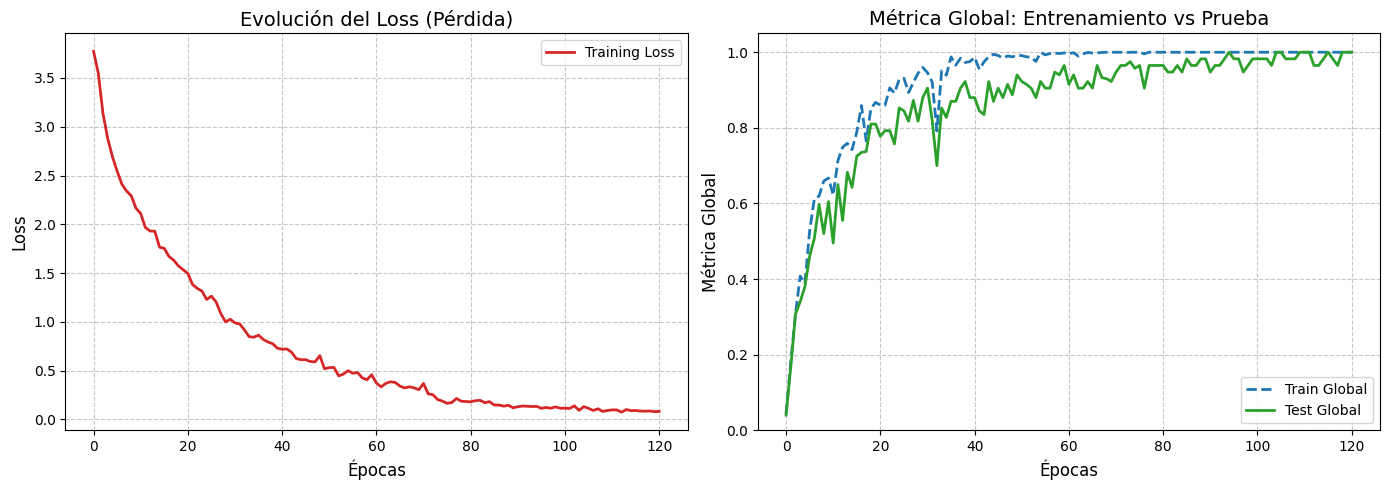

In [ ]:

# Usa automáticamente los historiales disponibles en memoria
if all(name in globals() for name in ["loss_epochs", "train_global_epochs", "test_global_epochs"]):
    plot_loss_epochs = loss_epochs
    plot_train_global_epochs = train_global_epochs
    plot_test_global_epochs = test_global_epochs
elif all(name in globals() for name in ["final_loss_epochs", "final_train_global_epochs", "final_test_global_epochs"]):
    plot_loss_epochs = final_loss_epochs
    plot_train_global_epochs = final_train_global_epochs
    plot_test_global_epochs = final_test_global_epochs
else:
    raise NameError("No hay métricas para graficar. Ejecuta primero una celda de entrenamiento.")

n_epochs = min(len(plot_loss_epochs), len(plot_train_global_epochs), len(plot_test_global_epochs))
if n_epochs == 0:
    raise ValueError("Las listas de métricas están vacías.")
x_epochs = list(range(1, n_epochs + 1))

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# Gráfico 1: Evolución de la Pérdida (Loss)
# ==========================================
ax1.plot(x_epochs, plot_loss_epochs[:n_epochs], label='Training Loss', color='tab:red', linewidth=2)
ax1.set_title('Evolución del Loss (Pérdida)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# ==========================================
# Gráfico 2: Métrica Global (Train vs Test)
# ==========================================
ax2.plot(x_epochs, plot_train_global_epochs[:n_epochs], label='Train Global', color='tab:blue', linestyle='--', linewidth=2)
ax2.plot(x_epochs, plot_test_global_epochs[:n_epochs], label='Test Global', color='tab:green', linestyle='-', linewidth=2)
ax2.set_title('Métrica Global: Entrenamiento vs Prueba', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Métrica Global', fontsize=12)
ax2.set_ylim([0.0, 1.05]) # La métrica suele ir de 0 a 1
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Ajustar el espaciado y mostrar la gráfica
plt.tight_layout()
plt.show()

## Optuna: búsqueda de hiperparámetros

Búsqueda automática de hiperparámetros para `ResNet4`, siguiendo la estructura del notebook 3.0 pero adaptada a la función `test_model` de este notebook.


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

N_CLASSES = int(len(np.unique(Y)))

activation_options = {
    "relu": torch.relu,
    "silu": torch.nn.functional.silu,
    "gelu": torch.nn.functional.gelu,
}


def build_model_from_trial(trial):
    activation_name = trial.suggest_categorical("activation", ["relu", "silu", "gelu"])
    apply_bn = trial.suggest_categorical("apply_bn", [True, False])
    drop_prob = trial.suggest_float("drop_prob", 0.10, 0.35)
    label_smoothing = trial.suggest_float("label_smoothing", 0.00, 0.16)

    model = ResNet4(
        dim_out=N_CLASSES,
        activation=activation_options[activation_name],
        apply_bn=apply_bn,
        drop_prob=drop_prob,
        link_function=nn.Softmax(dim=1),
        loss_function=nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    )

    return model


def objective(trial):
    torch.manual_seed(0)
    np.random.seed(0)

    lr = trial.suggest_float("lr", 5e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-3, log=True)
    beta1 = trial.suggest_float("beta1", 0.85, 0.95)
    beta2 = trial.suggest_float("beta2", 0.97, 0.9995)
    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)
    train_batch_size = trial.suggest_categorical("train_batch_size", [8, 16, 24, 32])
    patience = trial.suggest_int("patience", 5, 15)

    model = build_model_from_trial(trial).to(device)

    loss_epochs_trial, train_global_epochs_trial, test_global_epochs_trial = test_model(
        model=model,
        epochs=90,
        train_batch_size=train_batch_size,
        lr=lr,
        patience=patience,
        betas=(beta1, beta2),
        eps=eps,
        weight_decay=weight_decay,
        apply_scheduler=True,
        eval_each=1,
        train_dataset=train_dataset,
        test_dataset=test_dataset
    )

    best_epoch = int(np.argmax(test_global_epochs_trial))
    best_metric = float(test_global_epochs_trial[best_epoch])

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("best_train_global", float(train_global_epochs_trial[best_epoch]))
    trial.set_user_attr("best_test_global", best_metric)
    trial.set_user_attr("loss_at_best_epoch", float(loss_epochs_trial[best_epoch]))

    return best_metric


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
)

study.optimize(objective, n_trials=10)

print("Mejor metrica global:", study.best_value)
print("Mejores hiperparametros:", study.best_params)
print("Mejor epoca:", study.best_trial.user_attrs["best_epoch"])
print("Train global en esa epoca:", study.best_trial.user_attrs["best_train_global"])
print("Test global en esa epoca:", study.best_trial.user_attrs["best_test_global"])


[I 2026-04-28 18:44:39,361] A new study created in memory with name: no-name-39eb0627-8f1a-49f4-a6d3-9eee80549db6


Device: cuda
On epoch 1 got loss 3.52145 with train accuracy 0.14500, train top3 0.34833, train global 0.20600 and test accuracy 0.12500, test top3 0.30000, test global 0.17750                                                                                                                                         
On epoch 2 got loss 3.23115 with train accuracy 0.32917, train top3 0.58917, train global 0.40717 and test accuracy 0.17500, test top3 0.47500, test global 0.26500                                                                                                                                         
On epoch 3 got loss 3.01762 with train accuracy 0.40000, train top3 0.70000, train global 0.49000 and test accuracy 0.35000, test top3 0.65000, test global 0.44000                                                                                                                                         
On epoch 4 got loss 2.82176 with train accuracy 0.56833, train top3 0.83083, train g

[I 2026-04-28 18:48:40,414] Trial 0 finished with value: 1.0 and parameters: {'lr': 0.00019906996673933386, 'weight_decay': 0.0032859708169642424, 'beta1': 0.9231993941811405, 'beta2': 0.9876604252838126, 'eps': 2.0513382630874506e-09, 'train_batch_size': 24, 'patience': 12, 'activation': 'silu', 'apply_bn': True, 'drop_prob': 0.14585112746335846, 'label_smoothing': 0.04867875887352604}. Best is trial 0 with value: 1.0.


On epoch 90 got loss 0.56185 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.97500, test top3 1.00000, test global 0.98250                                                                                                                                        

Entrenamiento finalizado. Mejor época: 67 | test_global: 1.00000
On epoch 1 got loss 3.47636 with train accuracy 0.15583, train top3 0.39833, train global 0.22858 and test accuracy 0.17500, test top3 0.37500, test global 0.23500                                                                                                                                         
On epoch 2 got loss 3.15825 with train accuracy 0.39667, train top3 0.67417, train global 0.47992 and test accuracy 0.30000, test top3 0.65000, test global 0.40500                                                                                                                                         
On epoch 3 got loss 2.90955 wit

[I 2026-04-28 18:52:35,160] Trial 1 finished with value: 1.0 and parameters: {'lr': 0.0003464665317471063, 'weight_decay': 3.960515045685083e-05, 'beta1': 0.8791229140198041, 'beta2': 0.9880496603943102, 'eps': 1.901024531987038e-09, 'train_batch_size': 32, 'patience': 7, 'activation': 'silu', 'apply_bn': True, 'drop_prob': 0.11626289824631988, 'label_smoothing': 0.15182168596053333}. Best is trial 0 with value: 1.0.


...

On epoch 90 got loss 3.63086 with train accuracy 0.02917, train top3 0.08750, train global 0.04667 and test accuracy 0.02500, test top3 0.07500, test global 0.04000                                                                                                                                        

Entrenamiento finalizado. Mejor época: 9 | test_global: 0.05500
On epoch 1 got loss 4.53025 with train accuracy 0.02583, train top3 0.08333, train global 0.04308 and test accuracy 0.02500, test top3 0.07500, test global 0.04000                                                                                                                                         
On epoch 2 got loss 3.69557 with train accuracy 0.02583, train top3 0.08250, train global 0.04283 and test accuracy 0.02500, test top3 0.07500, test global 0.04000                                                                                                                                         
On epoch 3 got loss 3.68902 with

[I 2026-04-28 19:16:27,179] Trial 8 finished with value: 0.94 and parameters: {'lr': 0.00033892507693557413, 'weight_decay': 0.00039851625590699825, 'beta1': 0.8863629602379294, 'beta2': 0.9986675714402684, 'eps': 8.411909465645698e-08, 'train_batch_size': 16, 'patience': 5, 'activation': 'relu', 'apply_bn': False, 'drop_prob': 0.1598904726667431, 'label_smoothing': 0.023183179534595696}. Best is trial 0 with value: 1.0.


On epoch 90 got loss 0.39237 with train accuracy 0.99917, train top3 1.00000, train global 0.99942 and test accuracy 0.92500, test top3 0.97500, test global 0.94000                                                                                                                                        

Entrenamiento finalizado. Mejor época: 90 | test_global: 0.94000
On epoch 1 got loss 3.39769 with train accuracy 0.29500, train top3 0.61167, train global 0.39000 and test accuracy 0.25000, test top3 0.52500, test global 0.33250                                                                                                                                         
On epoch 2 got loss 3.01015 with train accuracy 0.45500, train top3 0.70917, train global 0.53125 and test accuracy 0.42500, test top3 0.65000, test global 0.49250                                                                                                                                         
On epoch 3 got loss 2.72688 wit

[I 2026-04-28 19:19:59,834] Trial 9 finished with value: 1.0 and parameters: {'lr': 0.0003041604129994602, 'weight_decay': 0.004424777779536137, 'beta1': 0.87420552715115, 'beta2': 0.9898279986484735, 'eps': 3.336101309469778e-08, 'train_batch_size': 16, 'patience': 11, 'activation': 'gelu', 'apply_bn': True, 'drop_prob': 0.11019378538869098, 'label_smoothing': 0.09454287091011869}. Best is trial 0 with value: 1.0.


On epoch 90 got loss 0.78730 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.97500, test top3 1.00000, test global 0.98250                                                                                                                                        

Entrenamiento finalizado. Mejor época: 89 | test_global: 1.00000
Mejor metrica global: 1.0
Mejores hiperparametros: {'lr': 0.00019906996673933386, 'weight_decay': 0.0032859708169642424, 'beta1': 0.9231993941811405, 'beta2': 0.9876604252838126, 'eps': 2.0513382630874506e-09, 'train_batch_size': 24, 'patience': 12, 'activation': 'silu', 'apply_bn': True, 'drop_prob': 0.14585112746335846, 'label_smoothing': 0.04867875887352604}
Mejor epoca: 67
Train global en esa epoca: 1.0
Test global en esa epoca: 1.0


## Reentrenamiento final con los mejores hiperparámetros

Reentrena `ResNet4` usando los mejores hiperparámetros encontrados por Optuna.


In [11]:
best = study.best_params
print("Hiperparametros optimos:", best)

final_model = ResNet4(
    dim_out=N_CLASSES,
    activation=activation_options[best["activation"]],
    apply_bn=best["apply_bn"],
    drop_prob=best["drop_prob"],
    link_function=nn.Softmax(dim=1),
    loss_function=nn.CrossEntropyLoss(label_smoothing=best["label_smoothing"])
).to(device)

final_loss_epochs, final_train_global_epochs, final_test_global_epochs = test_model(
    model=final_model,
    epochs=90,
    train_batch_size=best["train_batch_size"],
    lr=best["lr"],
    patience=best["patience"],
    betas=(best["beta1"], best["beta2"]),
    eps=best["eps"],
    weight_decay=best["weight_decay"],
    apply_scheduler=True,
    eval_each=1,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)

final_best_epoch = int(np.argmax(final_test_global_epochs))
final_best_metric = float(final_test_global_epochs[final_best_epoch])

print(f"Mejor epoca final: {final_best_epoch}")
print(f"Mejor test global final: {final_best_metric:.5f}")
print(f"Train global en mejor epoca: {final_train_global_epochs[final_best_epoch]:.5f}")
print(f"Loss en mejor epoca: {final_loss_epochs[final_best_epoch]:.5f}")

torch.save(final_model.state_dict(), "resnet18_4_0.pth")
print("Modelo guardado en resnet18_4_0.pth")


Hiperparametros optimos: {'lr': 0.00019906996673933386, 'weight_decay': 0.0032859708169642424, 'beta1': 0.9231993941811405, 'beta2': 0.9876604252838126, 'eps': 2.0513382630874506e-09, 'train_batch_size': 24, 'patience': 12, 'activation': 'silu', 'apply_bn': True, 'drop_prob': 0.14585112746335846, 'label_smoothing': 0.04867875887352604}
On epoch 1 got loss 3.51768 with train accuracy 0.13250, train top3 0.30917, train global 0.18550 and test accuracy 0.10000, test top3 0.32500, test global 0.16750                                                                                                                                         
On epoch 2 got loss 3.21145 with train accuracy 0.30250, train top3 0.64000, train global 0.40375 and test accuracy 0.17500, test top3 0.52500, test global 0.28000                                                                                                                                         
On epoch 3 got loss 2.99559 with train accuracy 0.43750, tra

## Entrenamiento manual

In [ ]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ResNet4(
    dim_out=40,
    activation=torch.nn.functional.gelu,
    apply_bn=True,
    drop_prob=0.11019378538869098,
    link_function=nn.Softmax(dim=1),
    loss_function=nn.CrossEntropyLoss(label_smoothing=0.09454287091011869)
).to(device)

loss_epochs, train_global_epochs, test_global_epochs = test_model(
    model=model,
    epochs=120,
    train_batch_size=16,
    lr=0.0003041604129994602,
    patience=11,
    betas=(0.87420552715115, 0.9898279986484735),
    eps=3.336101309469778e-08,
    weight_decay=0.004424777779536137,
    apply_scheduler=True,
    eval_each=1,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)

torch.save(model.state_dict(), "Best_model.pth")
print("Modelo guardado en Best_model.pth")

On epoch 1 got loss 3.39769 with train accuracy 0.29583, train top3 0.61167, train global 0.39058 and test accuracy 0.25000, test top3 0.52500, test global 0.33250                                                                                                                                         
On epoch 2 got loss 3.01012 with train accuracy 0.45417, train top3 0.70917, train global 0.53067 and test accuracy 0.42500, test top3 0.65000, test global 0.49250                                                                                                                                         
On epoch 3 got loss 2.72687 with train accuracy 0.41917, train top3 0.77000, train global 0.52442 and test accuracy 0.32500, test top3 0.77500, test global 0.46000                                                                                                                                         
On epoch 4 got loss 2.49206 with train accuracy 0.71250, train top3 0.93500, train global 0.77925

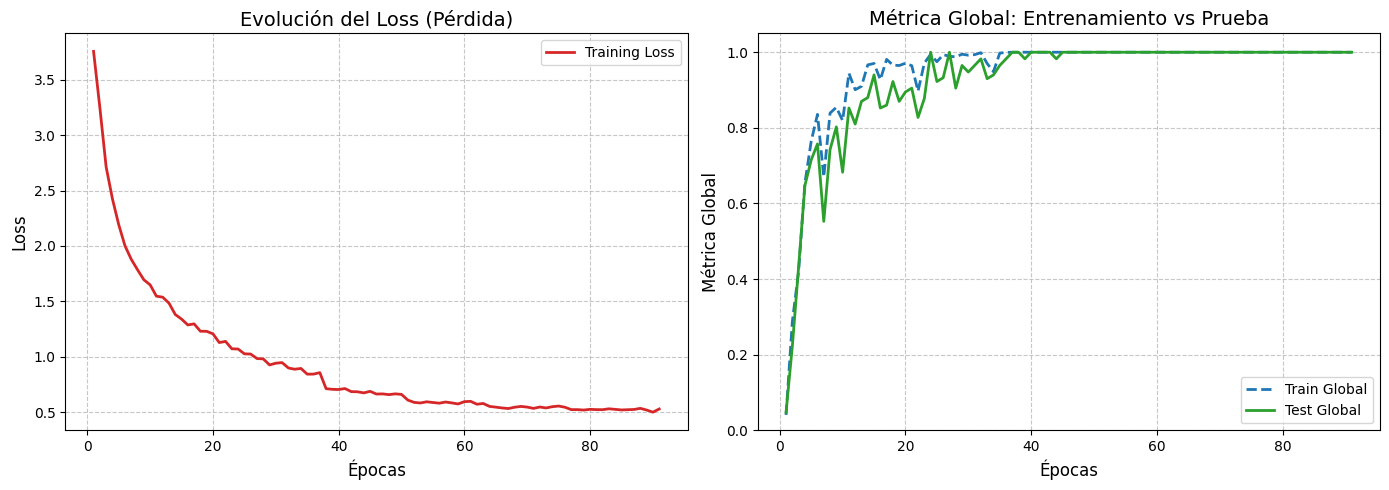

In [15]:
# Usa automáticamente los historiales disponibles en memoria
if all(name in globals() for name in ["loss_epochs", "train_global_epochs", "test_global_epochs"]):
    plot_loss_epochs = loss_epochs
    plot_train_global_epochs = train_global_epochs
    plot_test_global_epochs = test_global_epochs
elif all(name in globals() for name in ["final_loss_epochs", "final_train_global_epochs", "final_test_global_epochs"]):
    plot_loss_epochs = final_loss_epochs
    plot_train_global_epochs = final_train_global_epochs
    plot_test_global_epochs = final_test_global_epochs
else:
    raise NameError("No hay métricas para graficar. Ejecuta primero una celda de entrenamiento.")

n_epochs = min(len(plot_loss_epochs), len(plot_train_global_epochs), len(plot_test_global_epochs))
if n_epochs == 0:
    raise ValueError("Las listas de métricas están vacías.")
x_epochs = list(range(1, n_epochs + 1))

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# Gráfico 1: Evolución de la Pérdida (Loss)
# ==========================================
ax1.plot(x_epochs, plot_loss_epochs[:n_epochs], label='Training Loss', color='tab:red', linewidth=2)
ax1.set_title('Evolución del Loss (Pérdida)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# ==========================================
# Gráfico 2: Métrica Global (Train vs Test)
# ==========================================
ax2.plot(x_epochs, plot_train_global_epochs[:n_epochs], label='Train Global', color='tab:blue', linestyle='--', linewidth=2)
ax2.plot(x_epochs, plot_test_global_epochs[:n_epochs], label='Test Global', color='tab:green', linestyle='-', linewidth=2)
ax2.set_title('Métrica Global: Entrenamiento vs Prueba', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Métrica Global', fontsize=12)
ax2.set_ylim([0.0, 1.05]) # La métrica suele ir de 0 a 1
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Ajustar el espaciado y mostrar la gráfica
plt.tight_layout()
plt.show()